MULTIPLE LINEAR REGRESSION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =pd.read_csv('/content/ToyotaCorolla - MLR.csv')

In [3]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [4]:
df.shape

(1436, 11)

In [5]:
df.head(10)

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
5,12950,32,61000,Diesel,90,0,2000,3,4,5,1170
6,16900,27,94612,Diesel,90,0,2000,3,4,5,1245
7,18600,30,75889,Diesel,90,0,2000,3,4,5,1245
8,21500,27,19700,Petrol,192,0,1800,3,4,5,1185
9,12950,23,71138,Diesel,69,0,1900,3,4,5,1105


In [6]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [7]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [9]:
df[df.duplicated()]

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
113,24950,8,13253,Diesel,116,0,2000,5,4,5,1320


In [10]:
df.duplicated().sum()

1

In [11]:
df[df.duplicated(keep=False)]

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
112,24950,8,13253,Diesel,116,0,2000,5,4,5,1320
113,24950,8,13253,Diesel,116,0,2000,5,4,5,1320


In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

0

In [14]:
df.reset_index(drop=True,inplace=True)

In [15]:
df.dropna(axis=0,inplace=True)

In [16]:
df.shape

(1435, 11)

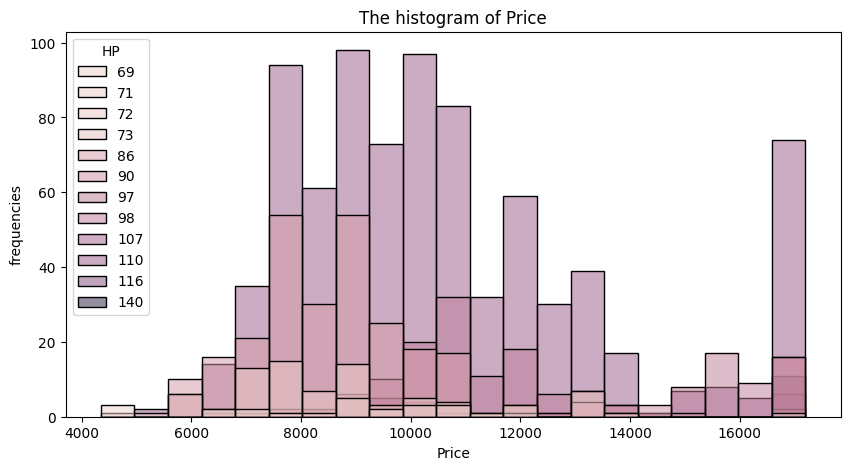

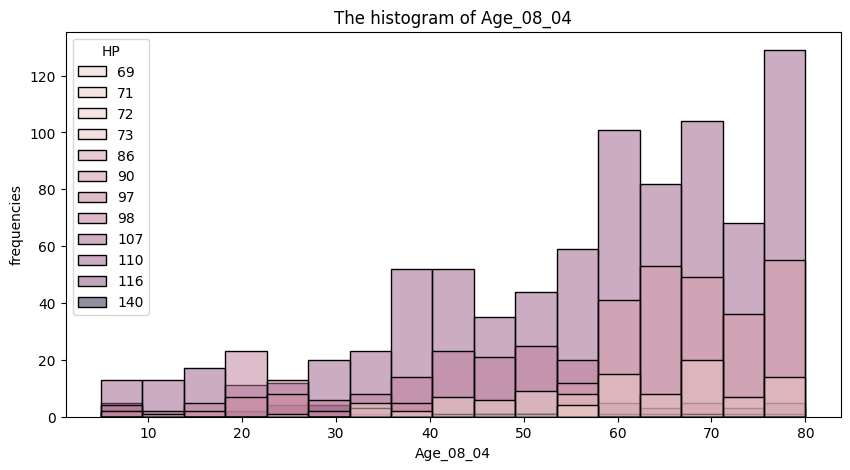

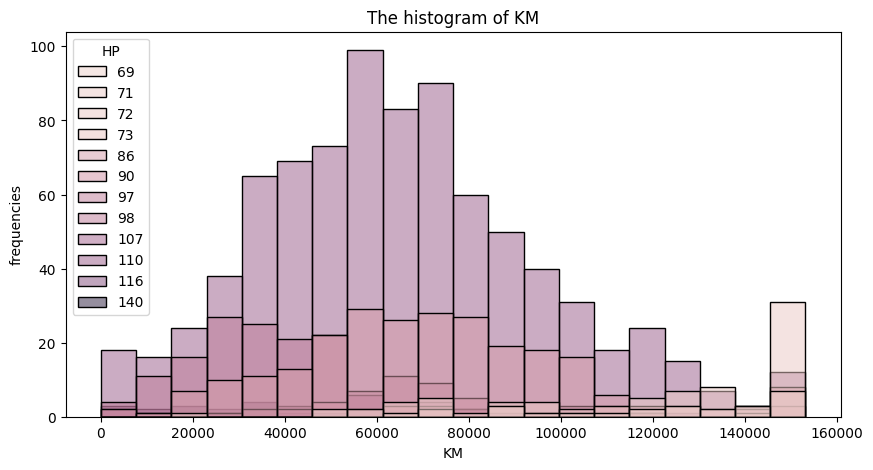

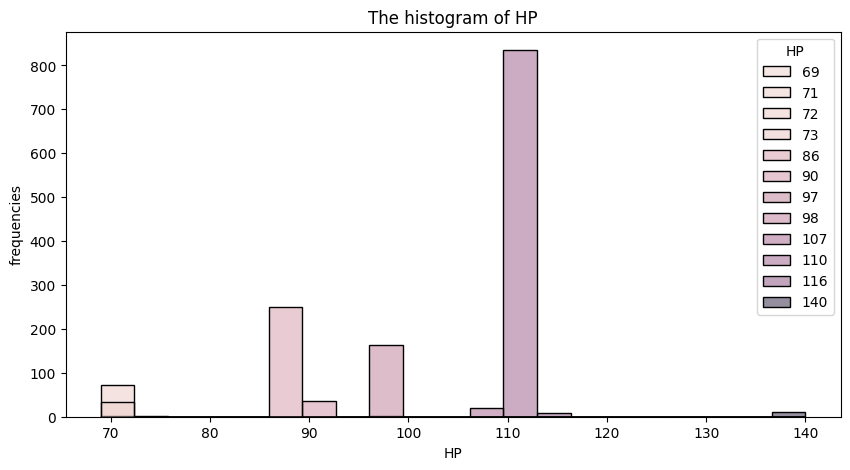

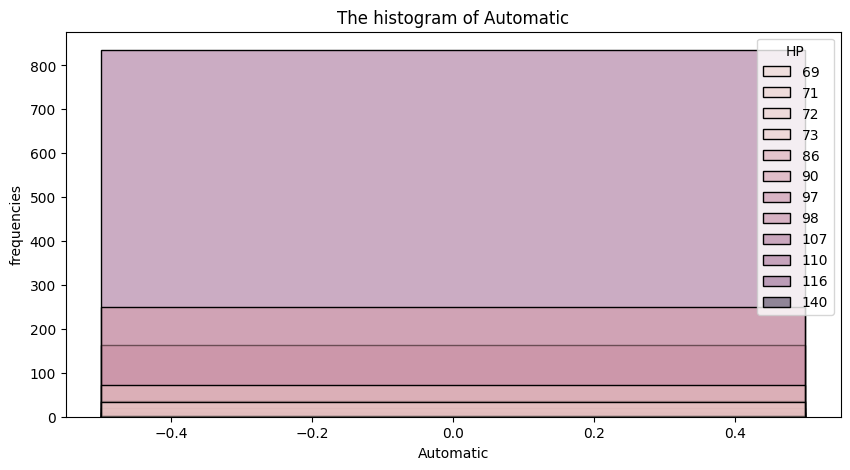

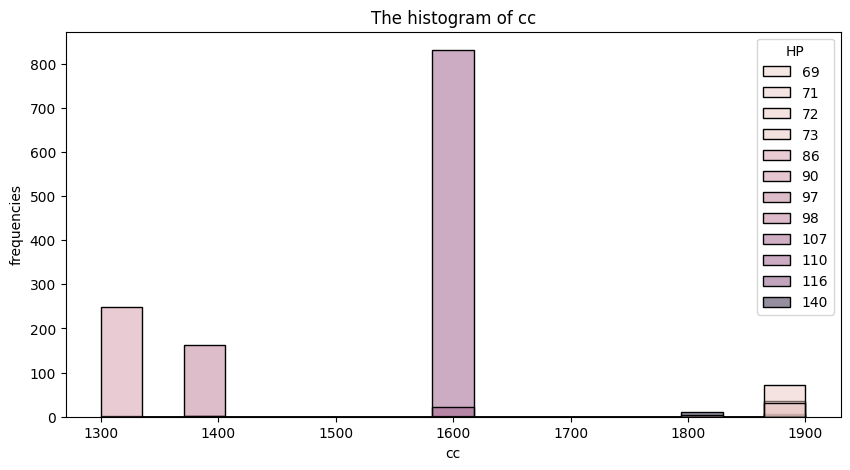

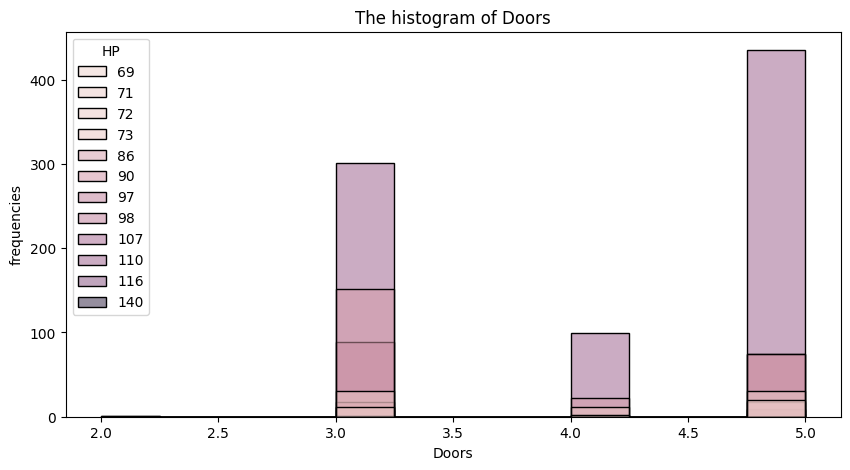

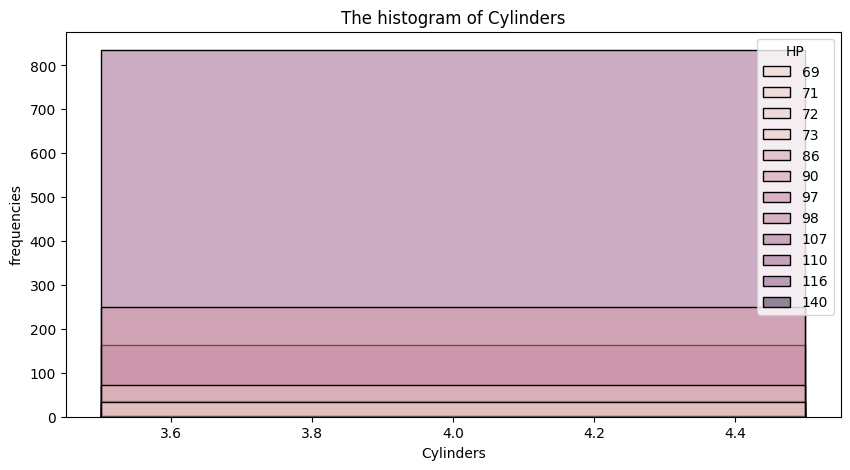

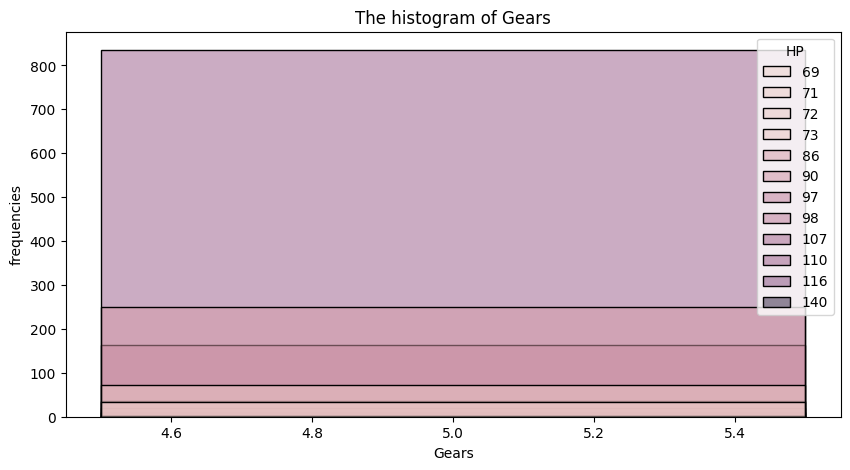

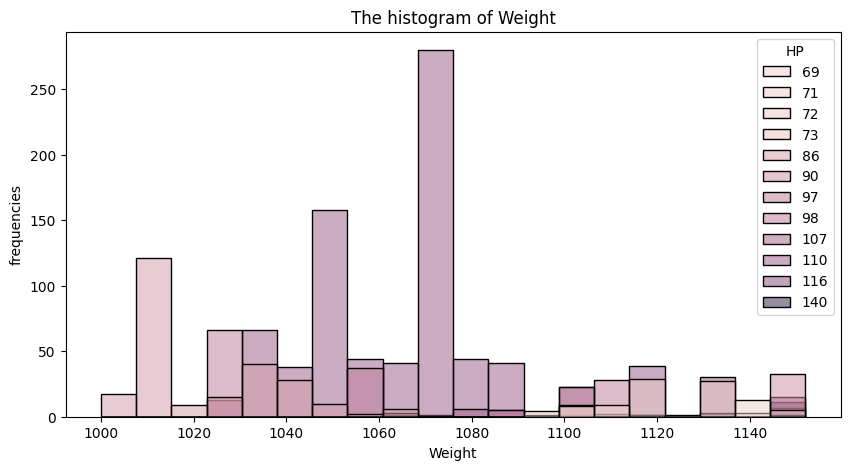

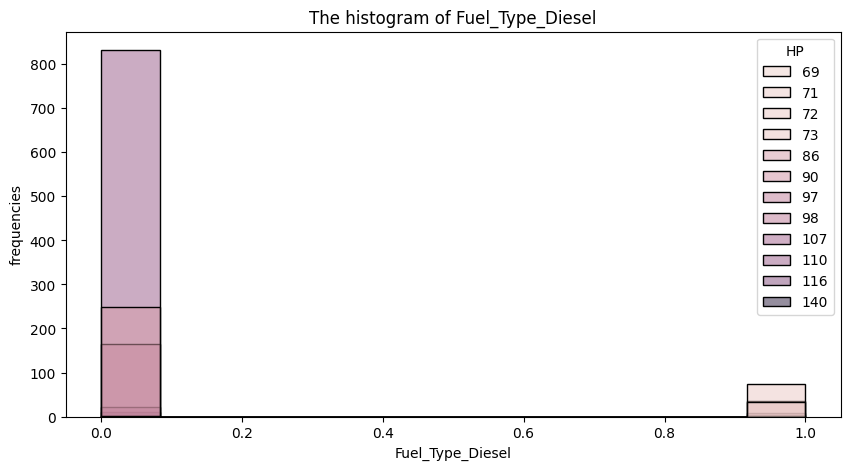

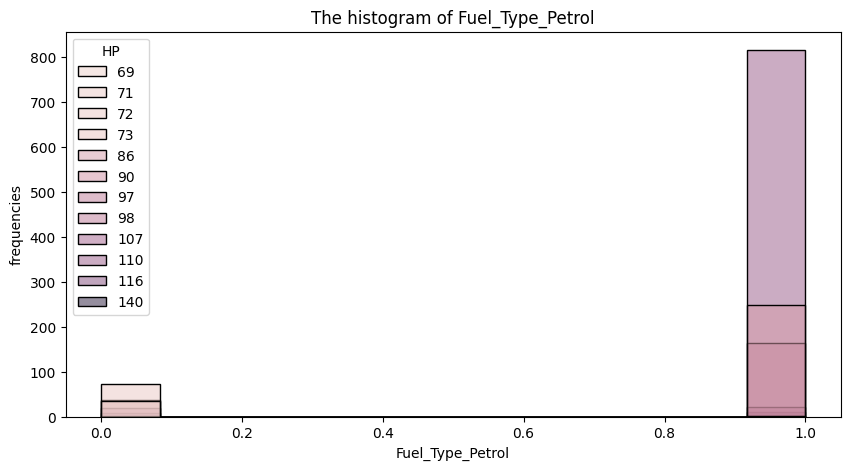

In [49]:
for col in df.columns:
  plt.figure(figsize=(10,5))
  sns.histplot(x=col,data=df,hue='HP')
  plt.title(f"The histogram of {col}")

  plt.xlabel(col)
  plt.ylabel('frequencies')
  plt.show()

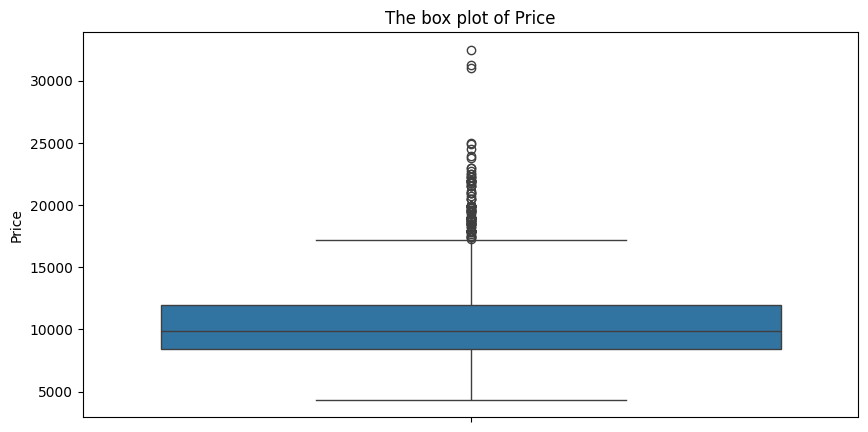

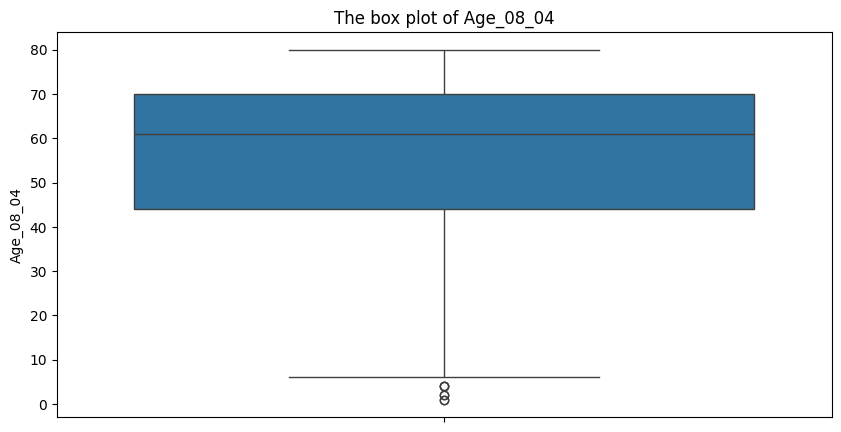

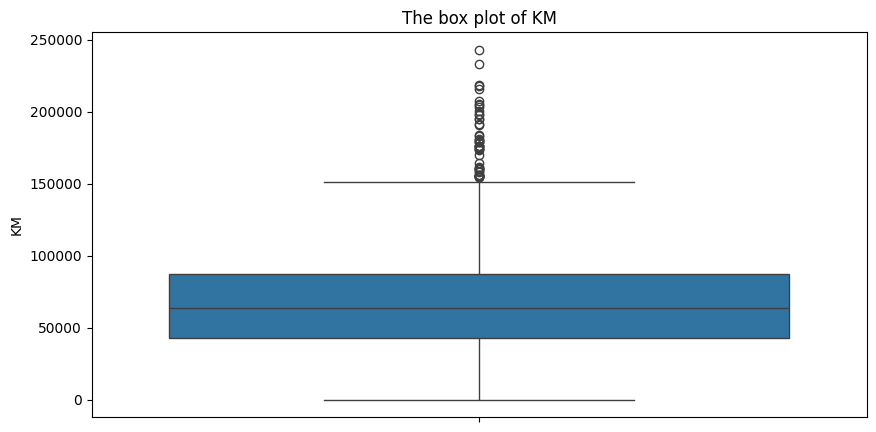

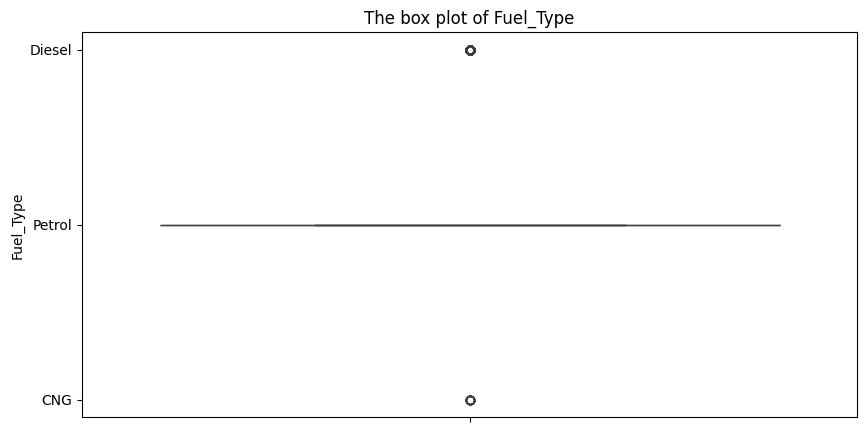

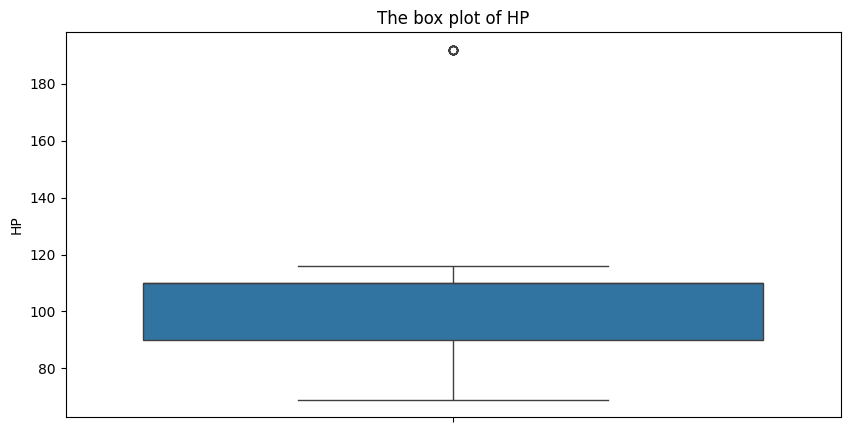

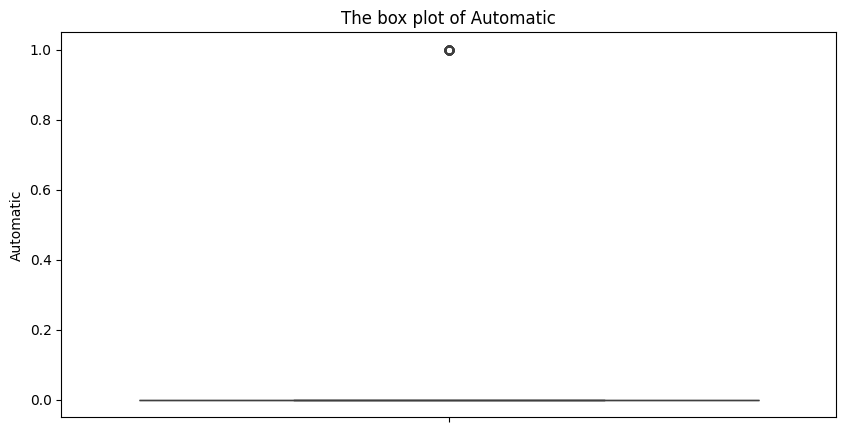

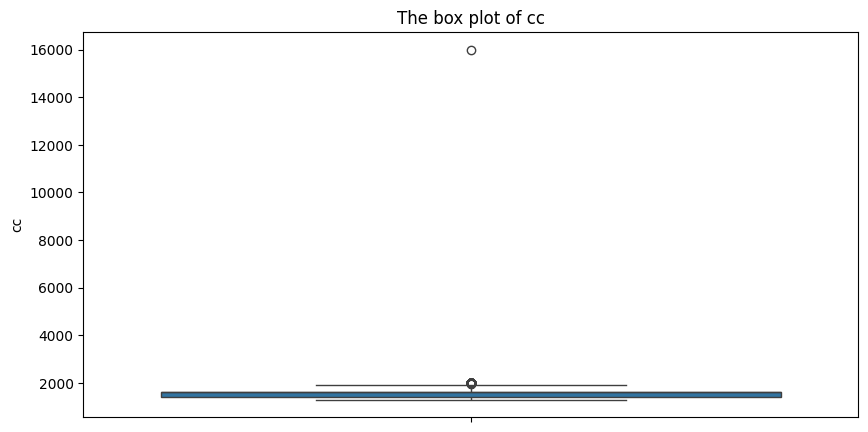

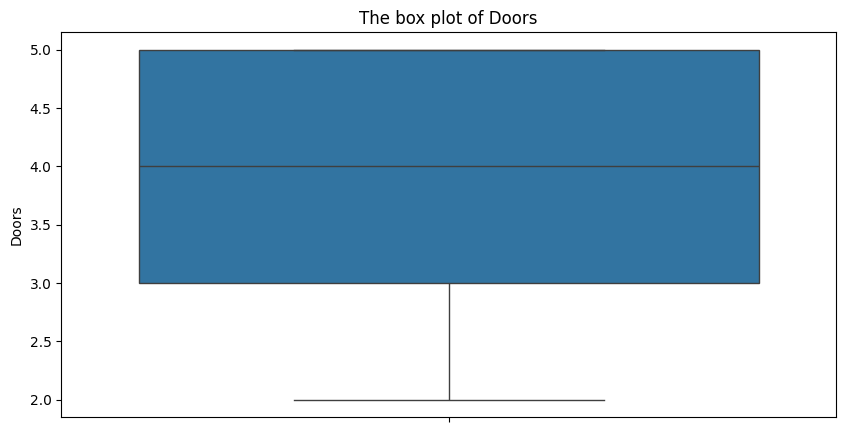

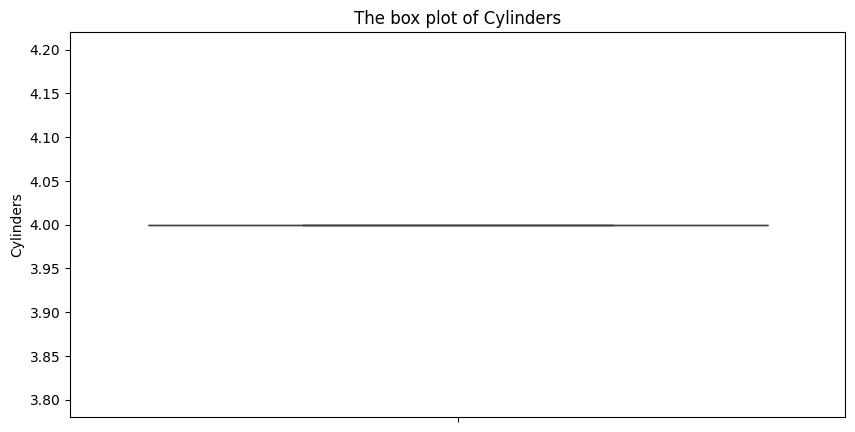

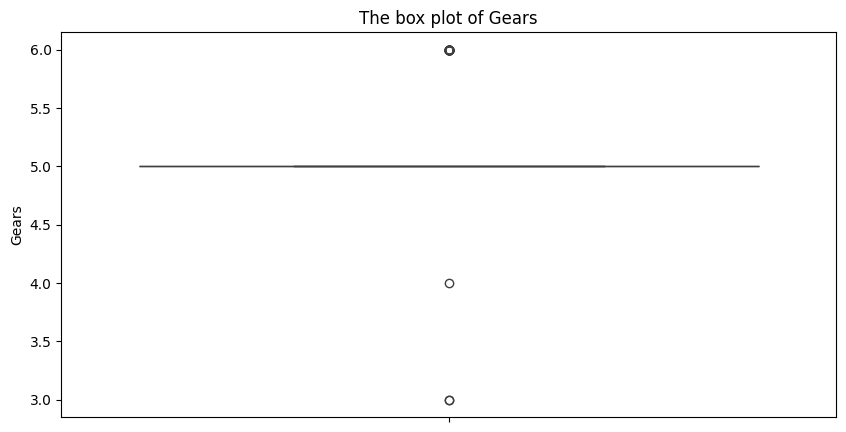

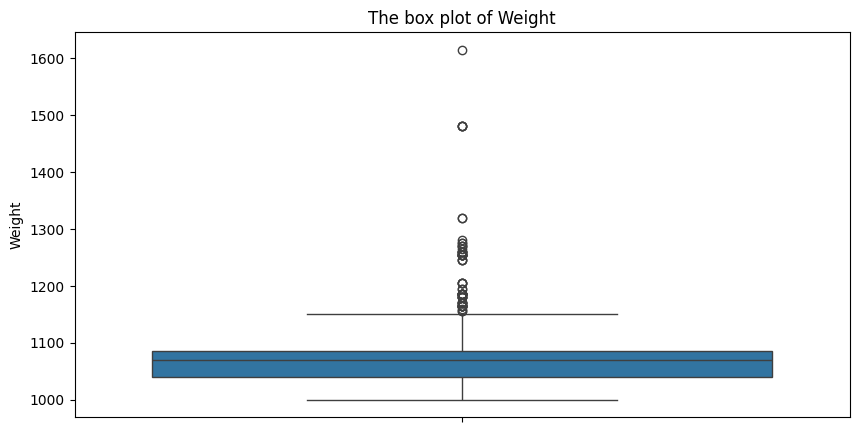

In [18]:
for col in df.columns:
  plt.figure(figsize=(10,5))
  sns.boxplot(df[col])
  plt.title(f"The box plot of {col}")
  plt.show()


In [19]:
for col in df.columns:
  if pd.api.types.is_numeric_dtype(df[col]):  # Check if column is numeric
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_bound, upper_bound)

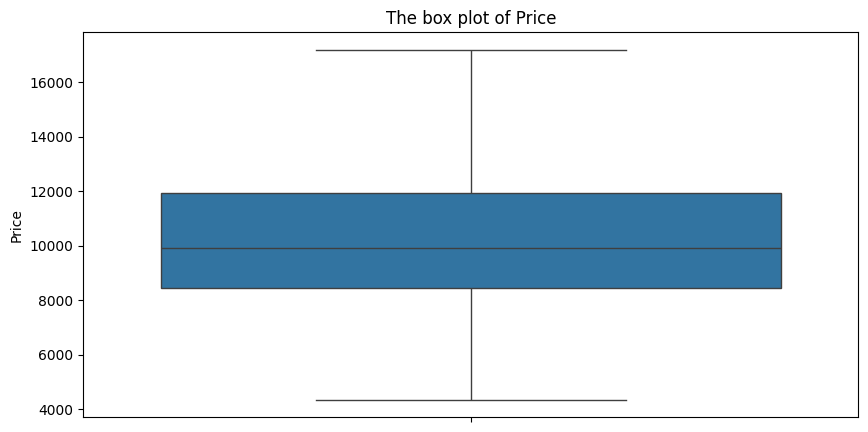

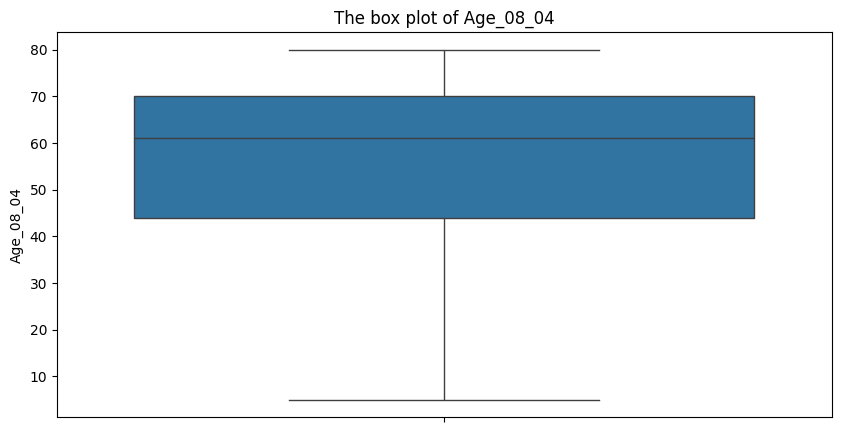

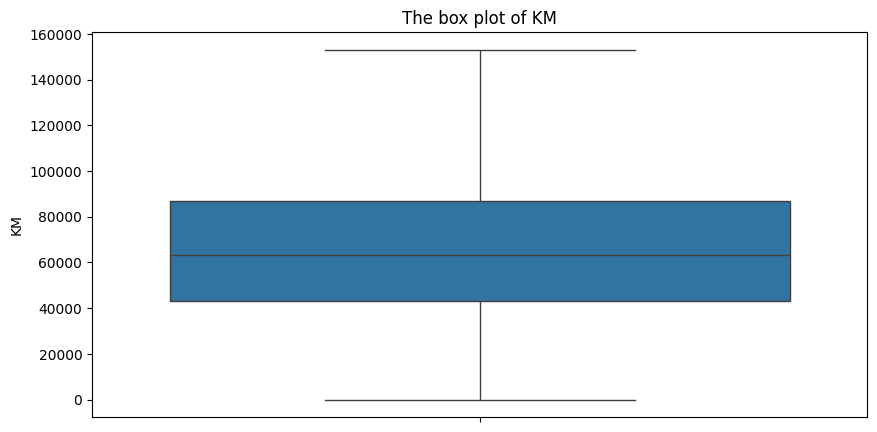

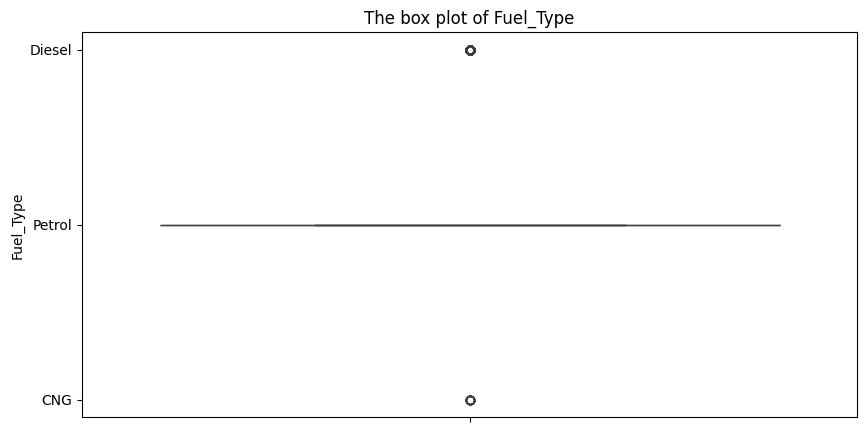

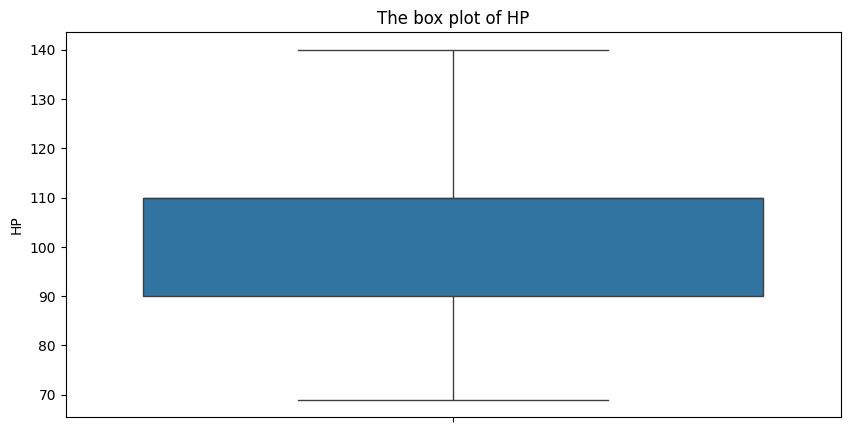

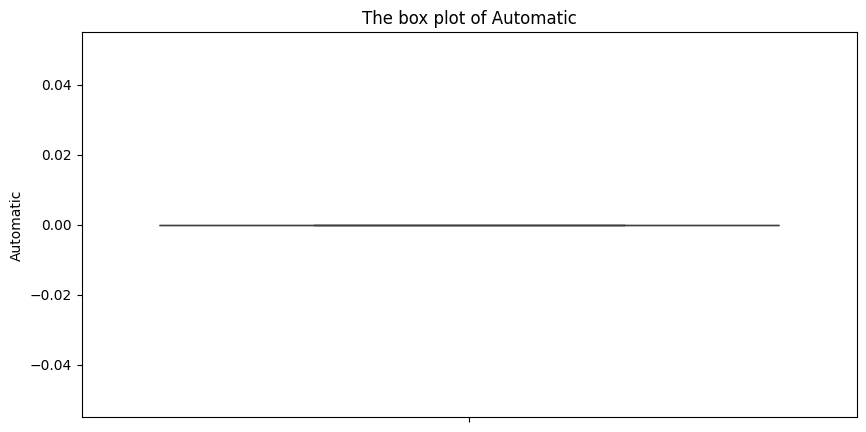

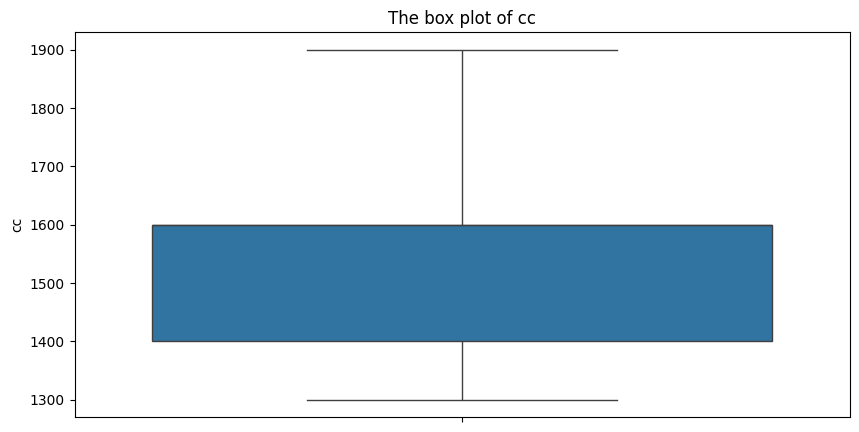

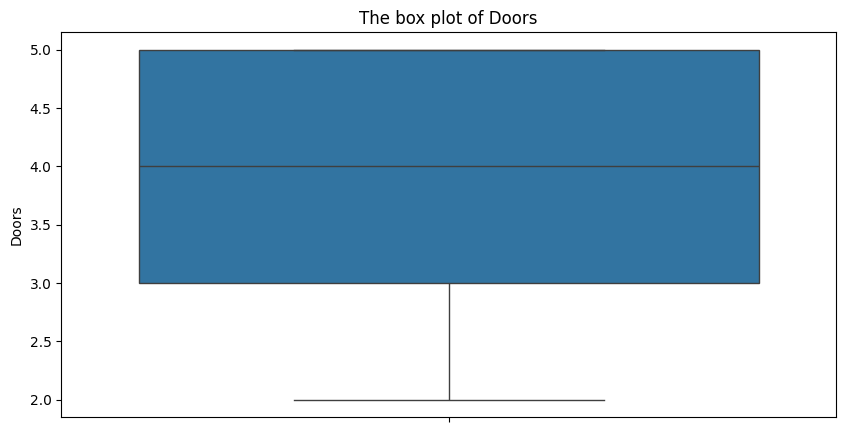

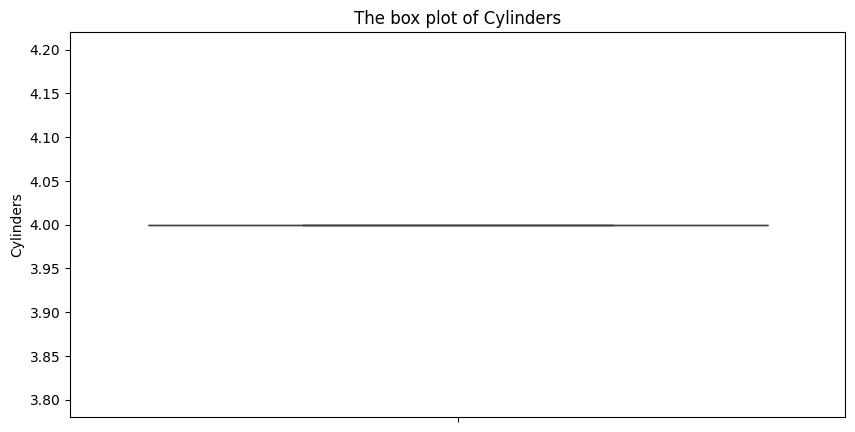

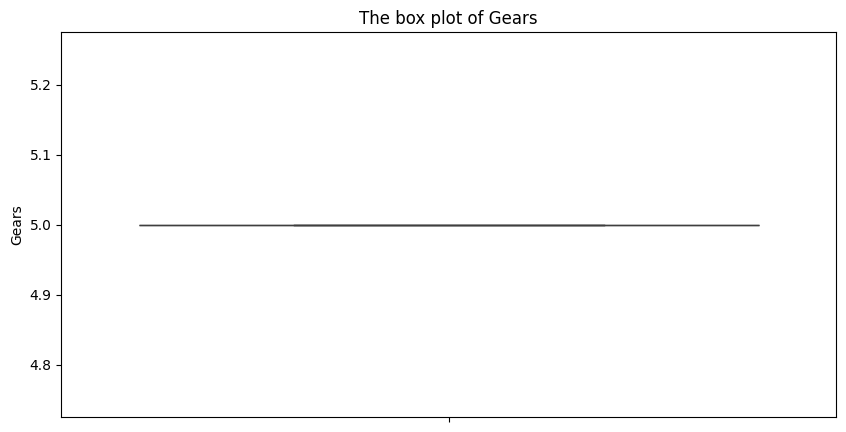

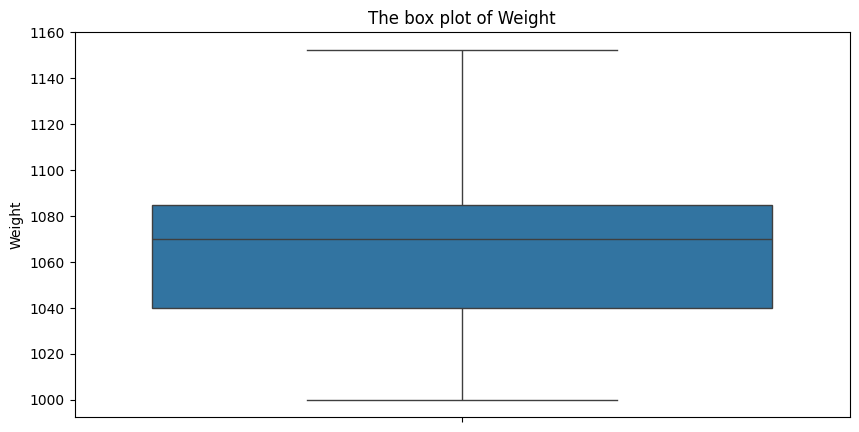

In [20]:
for col in df.columns:
  plt.figure(figsize=(10,5))
  sns.boxplot(df[col])
  plt.title(f"The box plot of {col}")
  plt.show()

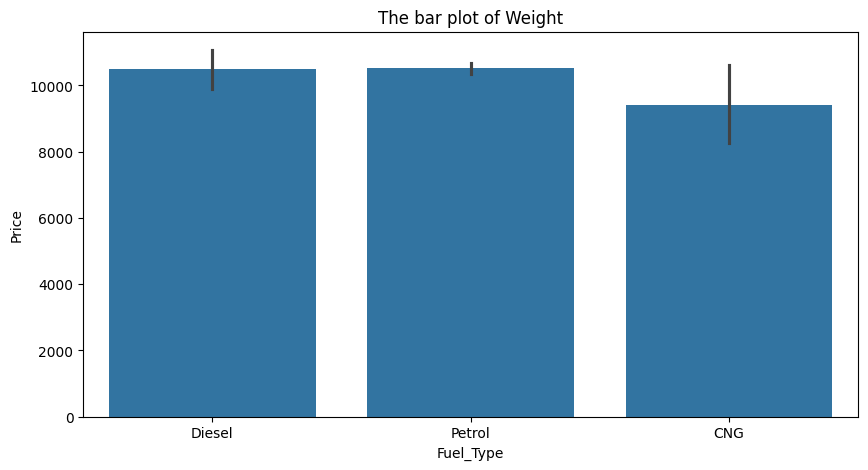

In [21]:
plt.figure(figsize=(10,5))
sns.barplot(x='Fuel_Type',y='Price',data=df)
plt.xlabel('Fuel_Type')
plt.title(f"The bar plot of {col}")
plt.show()

In [22]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [23]:
corr = df[['Price','Age_08_04','KM','HP','cc',
            'Doors','Weight']].corr()
corr

,Price,Age_08_04,KM,HP,cc,Doors,Weight
Price,1.000000,-0.895340,-0.607949,0.254427,0.129352,0.183010,0.507823
Age_08_04,-0.895340,1.000000,0.530670,-0.129602,-0.136644,-0.146704,-0.476150
KM,-0.607949,0.530670,1.000000,-0.329729,0.258680,-0.036618,0.000977
HP,0.254427,-0.129602,-0.329729,1.000000,0.098192,0.120139,0.024877
cc,0.129352,-0.136644,0.258680,0.098192,1.000000,0.138433,0.717782
Doors,0.183010,-0.146704,-0.036618,0.120139,0.138433,1.000000,0.381177
Weight,0.507823,-0.476150,0.000977,0.024877,0.717782,0.381177,1.000000


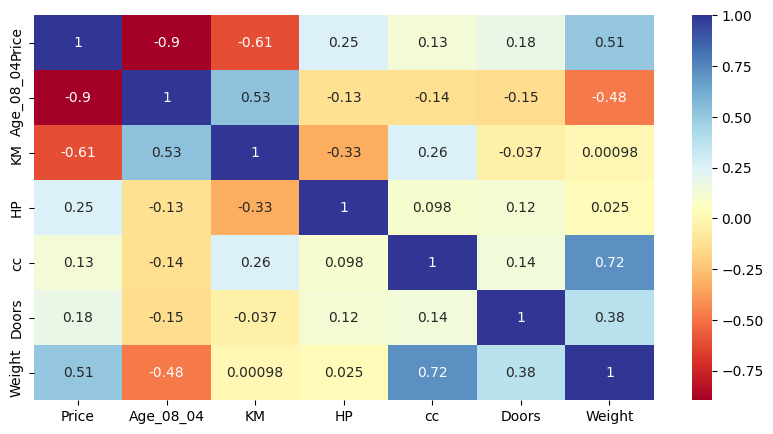

In [24]:
plt.figure(figsize=(10,5))
sns.heatmap(corr,annot=True,cmap="RdYlBu")

plt.show()

<Figure size 1000x500 with 0 Axes>

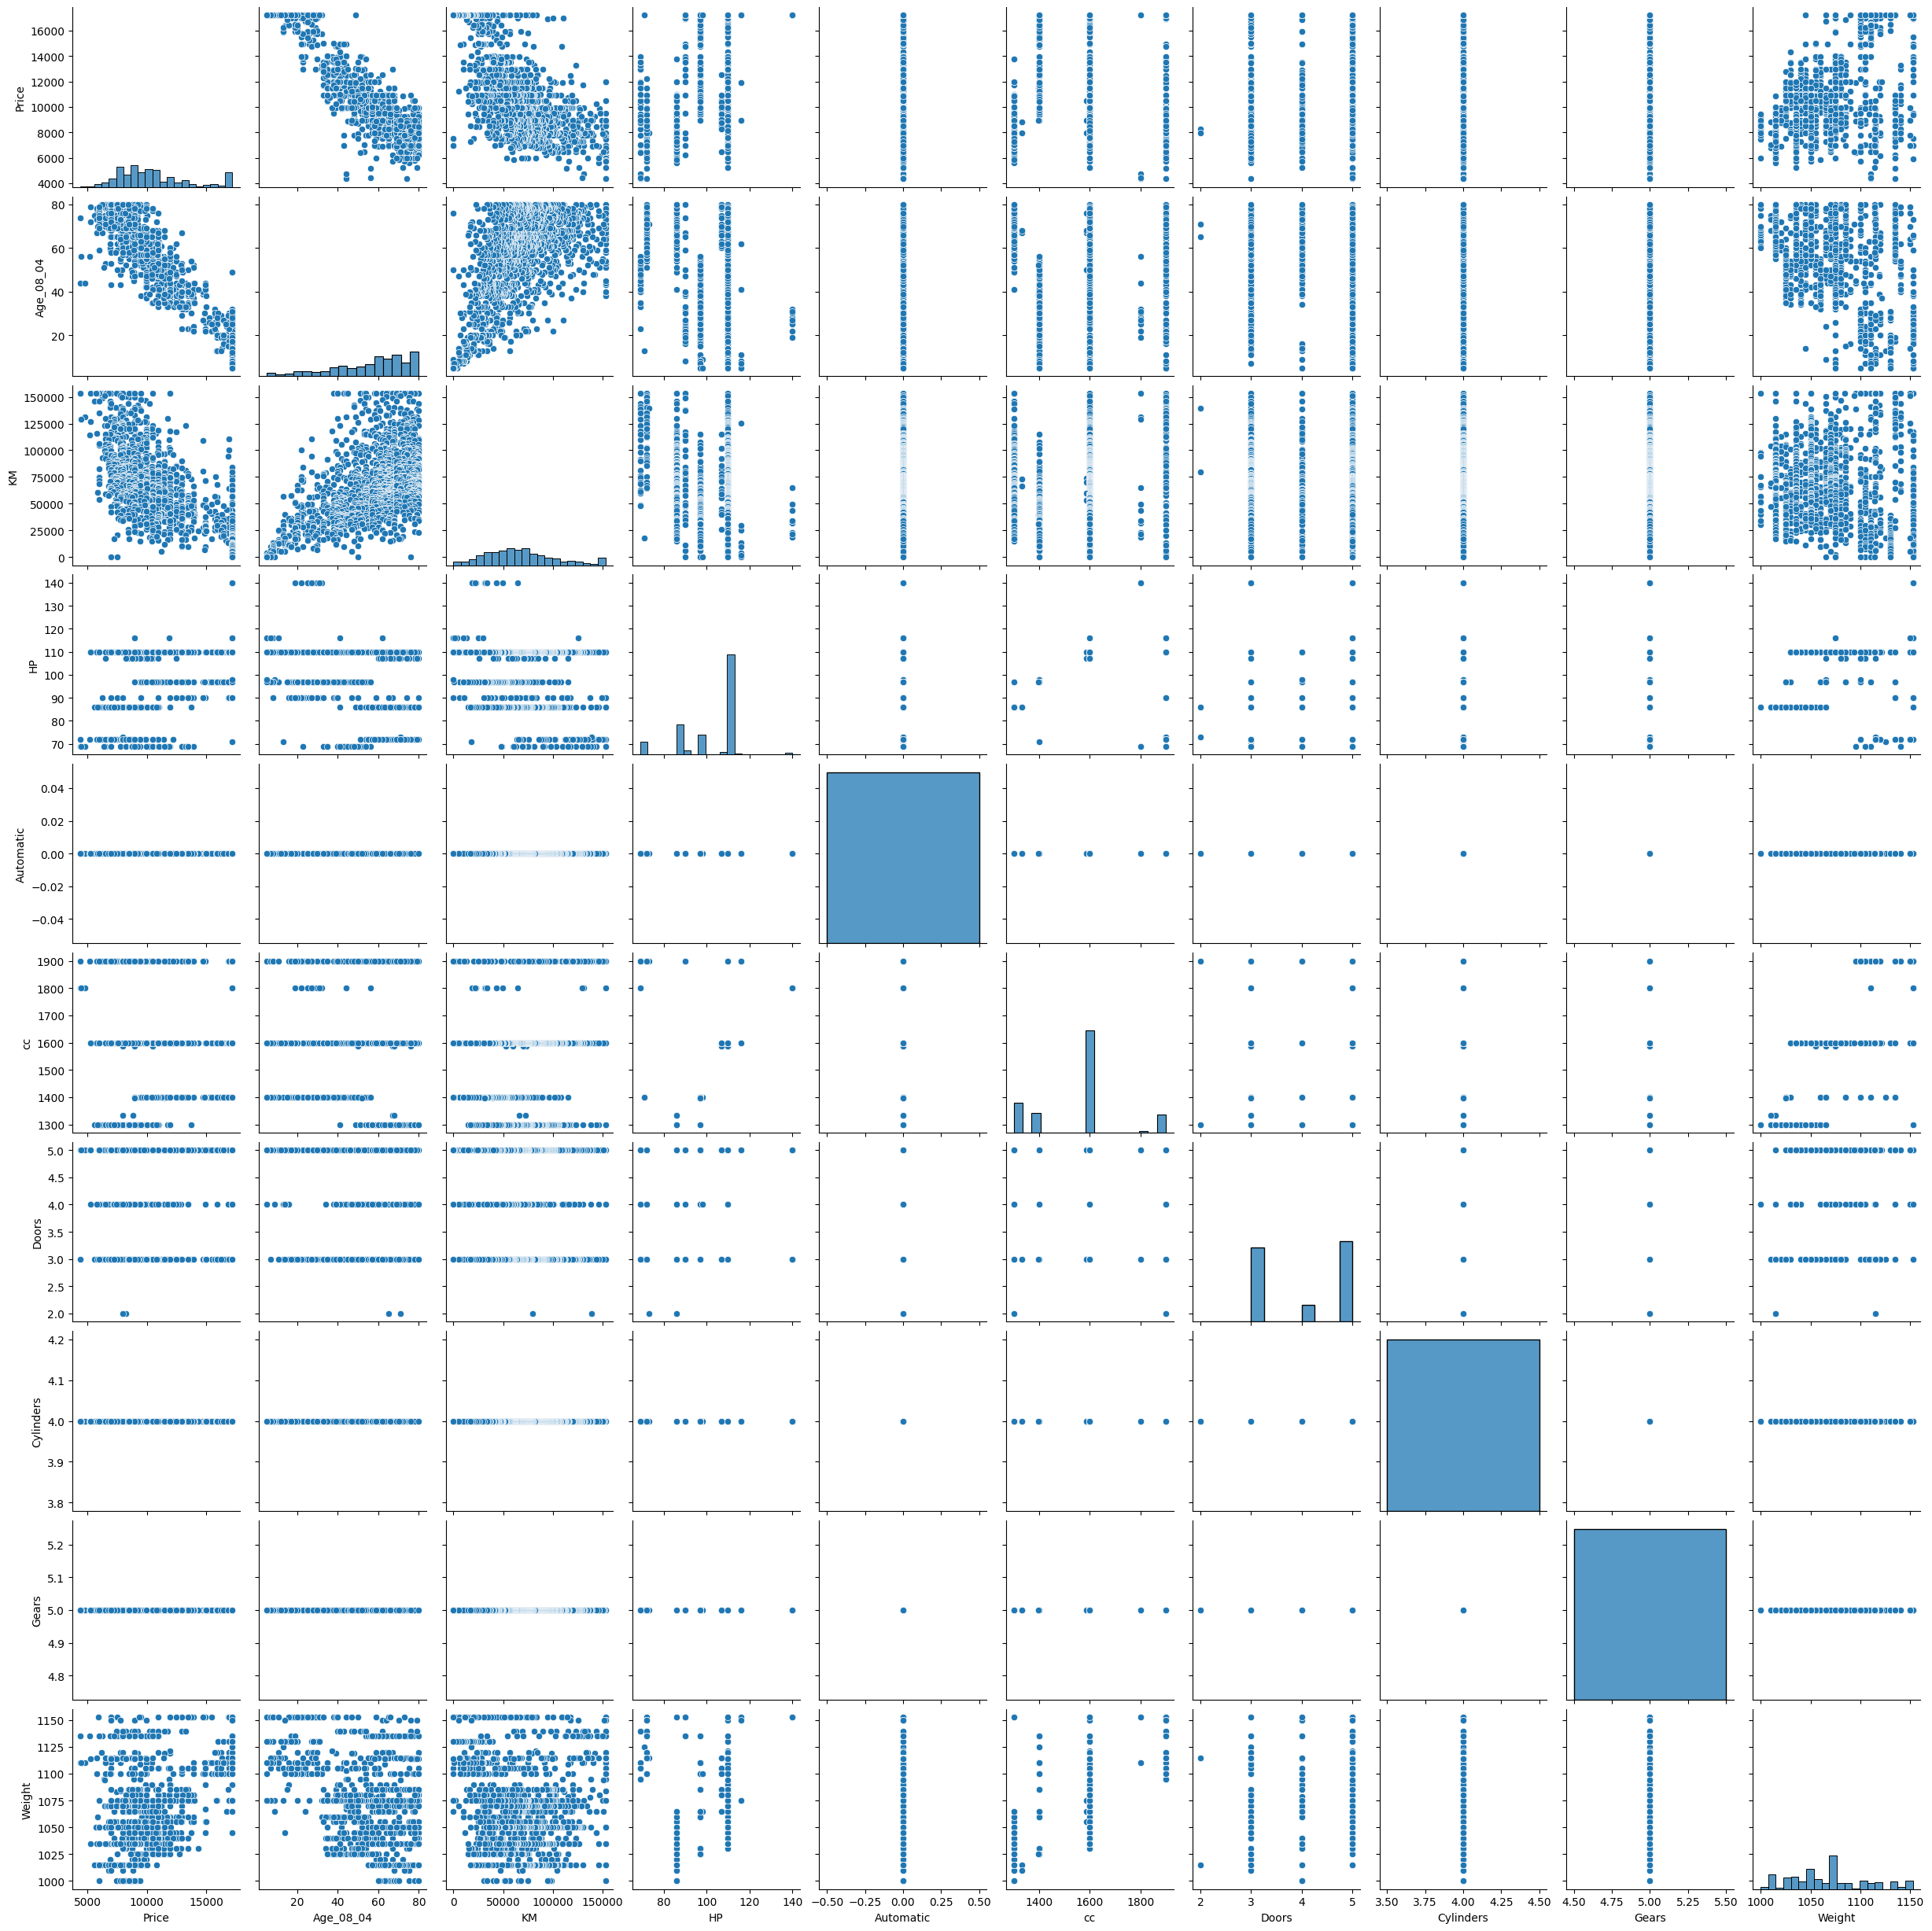

In [25]:
plt.figure(figsize=(10,5))
sns.pairplot(df)
plt.show()

In [26]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc',
       'Doors', 'Cylinders', 'Gears', 'Weight'],
      dtype='object')

In [27]:
pd.crosstab(df['Fuel_Type'],df['Gears'])

Gears,5
Fuel_Type,
CNG,17
Diesel,154
Petrol,1264


In [28]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
import plotly.express as px
from sklearn.preprocessing import StandardScaler


In [29]:
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986.0,Diesel,90,0,1900,3,4,5,1152.5
1,13750,23,72937.0,Diesel,90,0,1900,3,4,5,1152.5
2,13950,24,41711.0,Diesel,90,0,1900,3,4,5,1152.5
3,14950,26,48000.0,Diesel,90,0,1900,3,4,5,1152.5
4,13750,30,38500.0,Diesel,90,0,1900,3,4,5,1152.5
...,...,...,...,...,...,...,...,...,...,...,...
1430,7500,69,20544.0,Petrol,86,0,1300,3,4,5,1025.0
1431,10845,72,19000.0,Petrol,86,0,1300,3,4,5,1015.0
1432,8500,71,17016.0,Petrol,86,0,1300,3,4,5,1015.0
1433,7250,70,16916.0,Petrol,86,0,1300,3,4,5,1015.0


In [30]:
df=pd.get_dummies(df,columns=['Fuel_Type'],drop_first=True).astype(int)

In [31]:
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

In [32]:
df

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,1900,3,4,5,1152,1,0
1,13750,23,72937,90,0,1900,3,4,5,1152,1,0
2,13950,24,41711,90,0,1900,3,4,5,1152,1,0
3,14950,26,48000,90,0,1900,3,4,5,1152,1,0
4,13750,30,38500,90,0,1900,3,4,5,1152,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1430,7500,69,20544,86,0,1300,3,4,5,1025,0,1
1431,10845,72,19000,86,0,1300,3,4,5,1015,0,1
1432,8500,71,17016,86,0,1300,3,4,5,1015,0,1
1433,7250,70,16916,86,0,1300,3,4,5,1015,0,1


In [33]:
x=df.drop(columns=['Price'],axis=1)
y=df['Price']

In [34]:
y

,Price
0,13500
1,13750
2,13950
3,14950
4,13750
...,...
1430,7500
1431,10845
1432,8500
1433,7250


In [35]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=3)

In [36]:
# Model 1: Linear Regression
model1 = LinearRegression()
model1.fit(X_train, y_train)

LinearRegression()

In [37]:
y_pred=model1.predict(X_test)

In [38]:
y_pred

array([ 8257.31739563,  9531.51516939, 12330.80472518,  8100.30643256,
       16725.07774722, 12635.21593482, 10316.30863805, 10625.37634754,
        9814.17326974,  8816.12654994, 16348.9927931 ,  9910.42136081,
       10005.54014392,  8190.90247749, 11131.7597534 ,  7825.33635002,
       11230.12771883,  7682.48246954, 11061.18408425,  9153.40107988,
        7635.49055975,  9500.96058185, 12128.84973911,  8360.66911614,
        9516.15532055, 12566.71847887, 12078.27306125, 10662.38693705,
       10961.13449274, 10171.29925219, 12890.30612436,  9184.99344715,
        8513.11348406, 10237.87282895,  7646.98059813,  8365.07188458,
       10217.61915076, 12441.47583648, 12239.75279798, 10184.87530211,
        9947.47057704,  8191.50716703, 11645.11848104, 12634.02400056,
       11323.21213108, 10353.36724951, 11568.05811846,  8986.56461055,
       15071.59688341, 10509.15944402, 15572.2163615 , 12722.81223968,
       10452.59137184, 15568.21556848, 15975.51059339, 11127.51435876,
      

In [39]:
r2 = r2_score(y_test, y_pred)
print(f"R-squared:{r2}")

R-squared:0.8570205519500887


In [40]:
mse=mean_squared_error(y_test,y_pred)
print(f"Mean Squared Error:{mse}")

Mean Squared Error:1269373.4669103178


In [41]:
y_pred_df = pd.DataFrame({'actual': y,
                         'predicted_val':model1.predict(x)})

In [42]:
y_pred_df

,actual,predicted_val
0,13500,15381.003776
1,13750,14986.382741
2,13950,15354.889899
3,14950,15046.601739
4,13750,14765.752105
...,...,...
1430,7500,9136.763758
1431,10845,8607.532959
1432,8500,8744.030023
1433,7250,8851.878247


In [43]:
y_pred_df['predicted_val'].mean()-y_pred_df['actual'].mean()

22.43592807944333

In [44]:
y_pred_df['actual'].mean()

10495.964459930314

In [45]:

# Model 2: Ridge Regression
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

r2_ridge = r2_score(y_test, y_pred_ridge)
print(f"Ridge Regression - R-squared: {r2_ridge}")
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
print(f"Ridge Regression - Mean Squared Error: {mse_ridge}")

# Model 3: Lasso Regression
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

r2_lasso = r2_score(y_test, y_pred_lasso)
print(f"Lasso Regression - R-squared: {r2_lasso}")
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print(f"Lasso Regression - Mean Squared Error: {mse_lasso}")


Ridge Regression - R-squared: 0.8570459288534085
Ridge Regression - Mean Squared Error: 1269148.170420607
Lasso Regression - R-squared: 0.8570325192084148
Lasso Regression - Mean Squared Error: 1269267.2214296001


### **1. What is Normalization & Standardization and how is it helpful?**
**Normalization and Standardization are two techniques used to rescale numerical data to improve the performance of machine learning algorithms.**

**Normalization (Min-Max Scaling)**  


**It scales the data to a fixed range, usually [0,1] or [-1,1].**

### **2. What techniques can be used to address multicollinearity in multiple linear regression?**

**Multicollinearity occurs when two or more independent variables in a regression model are highly correlated, making it difficult to determine their individual effects on the dependent variable.**